<a href="https://colab.research.google.com/github/sameerkarur/Data_science/blob/main/03_IITK_AIML_Core_Machine_Learning/projects/Employee_Turnover_Analytics/Employee_Turnover_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Turnover Analytics

**Course-end Project 2 | IITK AIML Core: Machine Learning**

**Problem Objective:** Build ML models to predict employee turnover at Portobello Tech, understand key drivers via EDA and clustering, handle class imbalance with SMOTE, and recommend retention strategies by risk zone.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv('datasets/HR_comma_sep.csv')
# Kaggle export uses 'sales' for department name
if 'sales' in df.columns and 'Department' not in df.columns:
    df = df.rename(columns={'sales': 'Department'})
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Dataset shape: (14999, 10)
Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## 2. Data Quality Checks — Missing Values

In [3]:
print('Info:')
df.info()
print('\nMissing values per column:')
print(df.isna().sum())
print(f'\nTotal missing values: {df.isna().sum().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print('\nTarget (left) distribution:')
print(df['left'].value_counts())
print(df['left'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                    

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,NaN,NaN,NaN,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,NaN,NaN,NaN,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,NaN,NaN,NaN,3.803054,1.232592,2.0,3.0,4.0,5.0,7.0
average_montly_hours,14999.0,NaN,NaN,NaN,201.050337,49.943099,96.0,156.0,200.0,245.0,310.0
time_spend_company,14999.0,NaN,NaN,NaN,3.498233,1.460136,2.0,3.0,3.0,4.0,10.0
Work_accident,14999.0,NaN,NaN,NaN,0.14461,0.351719,0.0,0.0,0.0,0.0,1.0
left,14999.0,NaN,NaN,NaN,0.238083,0.425924,0.0,0.0,0.0,0.0,1.0
promotion_last_5years,14999.0,NaN,NaN,NaN,0.021268,0.144281,0.0,0.0,0.0,0.0,1.0
Department,14999,10,sales,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary,14999,3,low,7316,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Data quality conclusion:** No missing values in the provided dataset. Target `left` is imbalanced (~24% left vs ~76% stayed), so SMOTE will be applied on the training set later.

## 3. Exploratory Data Analysis — Factors Driving Turnover

### 3.1 Correlation Heatmap (Numerical Features)

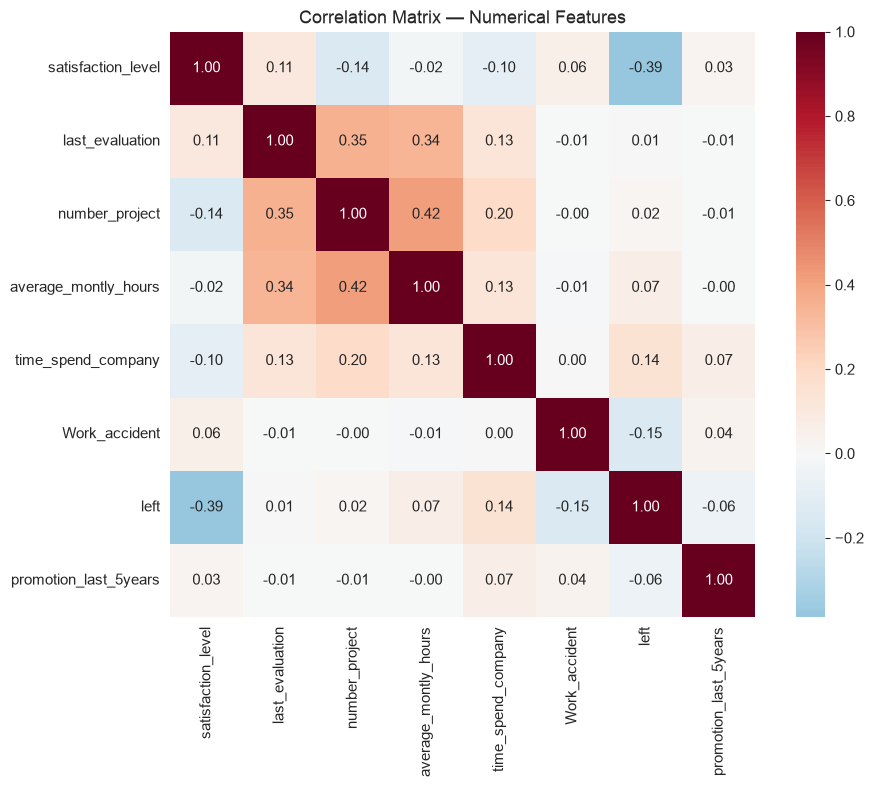

Correlation with left (turnover):
satisfaction_level      -0.388375
Work_accident           -0.154622
time_spend_company       0.144822
average_montly_hours     0.071287
promotion_last_5years   -0.061788
number_project           0.023787
last_evaluation          0.006567
Name: left, dtype: float64


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

print('Correlation with left (turnover):')
print(corr['left'].drop('left').sort_values(key=abs, ascending=False))

### 3.2 Distribution Plots

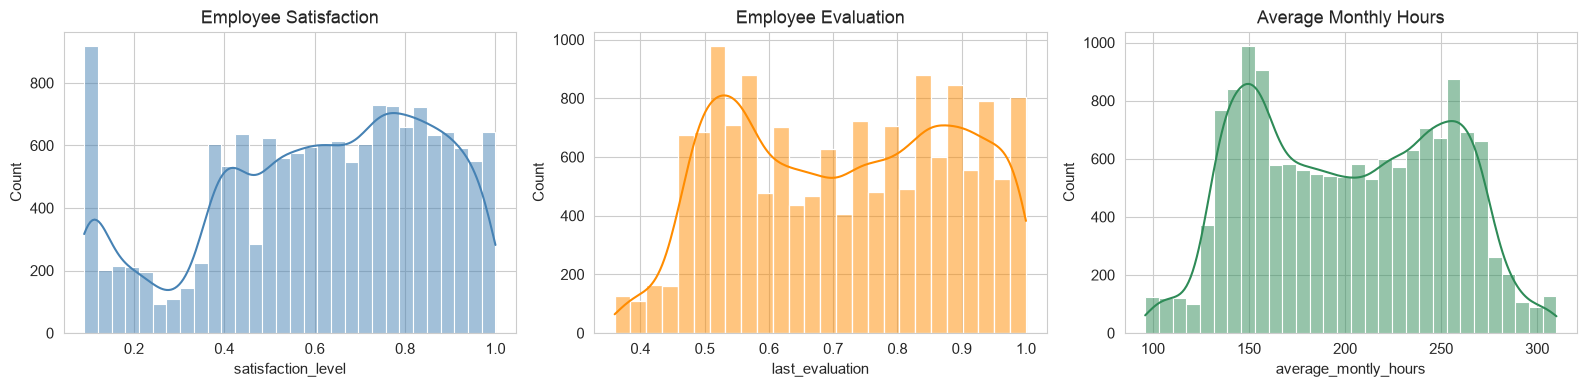

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Employee Satisfaction')
sns.histplot(df['last_evaluation'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Employee Evaluation')
sns.histplot(df['average_montly_hours'], kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('Average Monthly Hours')
plt.tight_layout()
plt.show()

### 3.3 Project Count: Left vs Stayed

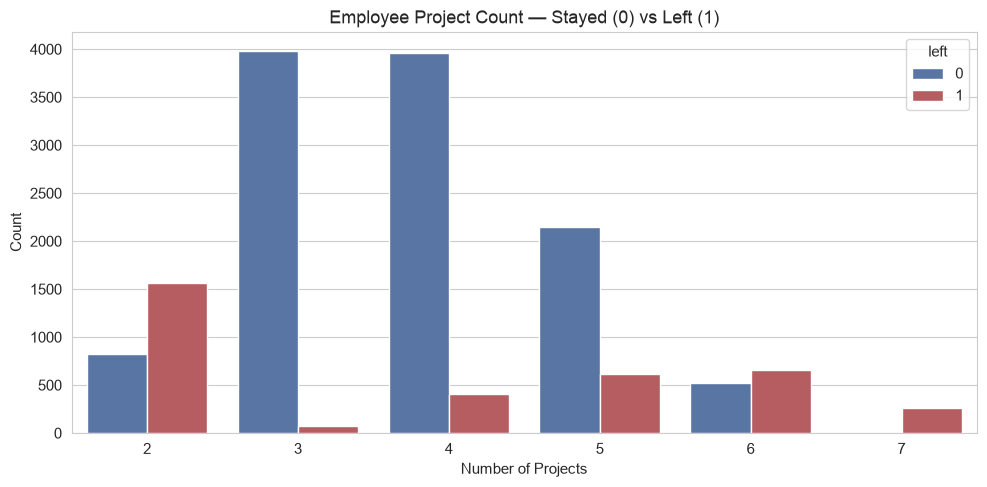

Turnover rate by number_project:
number_project
2     65.6%
3      1.8%
4      9.4%
5     22.2%
6     55.8%
7    100.0%
Name: left, dtype: str


In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='number_project', hue='left', palette=['#4C72B0', '#C44E52'])
plt.title('Employee Project Count — Stayed (0) vs Left (1)')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.legend(title='left')
plt.tight_layout()
plt.show()

print('Turnover rate by number_project:')
print(df.groupby('number_project')['left'].mean().mul(100).round(1).astype(str) + '%')

**Inferences from project-count plot:**
- Employees with **very few projects (2)** show high turnover — possible under-utilization / disengagement.
- Employees with **many projects (6–7)** also leave more — likely overwork / burnout.
- Mid-range project loads (~3–4) tend to have lower leave rates — a healthier workload band.

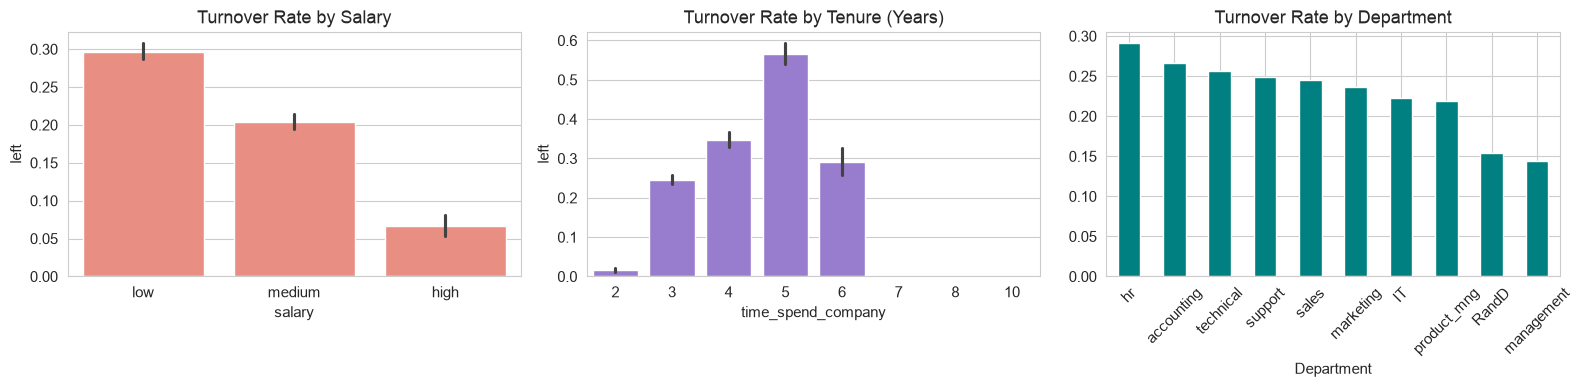

In [8]:
# Extra EDA: salary, tenure, department
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=df, x='salary', y='left', order=['low', 'medium', 'high'], ax=axes[0], color='salmon')
axes[0].set_title('Turnover Rate by Salary')
sns.barplot(data=df, x='time_spend_company', y='left', ax=axes[1], color='mediumpurple')
axes[1].set_title('Turnover Rate by Tenure (Years)')
dept_rate = df.groupby('Department')['left'].mean().sort_values(ascending=False)
dept_rate.plot(kind='bar', ax=axes[2], color='teal')
axes[2].set_title('Turnover Rate by Department')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Clustering Employees Who Left (Satisfaction & Evaluation)

In [9]:
left_emp = df[df['left'] == 1][['satisfaction_level', 'last_evaluation', 'left']].copy()
print(f'Employees who left: {len(left_emp)}')

X_left = left_emp[['satisfaction_level', 'last_evaluation']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
left_emp['cluster'] = kmeans.fit_predict(X_left)

print('Cluster sizes:')
print(left_emp['cluster'].value_counts().sort_index())
print('\nCluster centers (satisfaction, evaluation):')
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['satisfaction_level', 'last_evaluation'])
centers.index = [f'Cluster {i}' for i in range(3)]
display(centers.round(3))

Employees who left: 3571
Cluster sizes:
cluster
0    1650
1     977
2     944
Name: count, dtype: int64

Cluster centers (satisfaction, evaluation):


,satisfaction_level,last_evaluation
Cluster 0,0.410,0.517
Cluster 1,0.809,0.912
Cluster 2,0.111,0.869


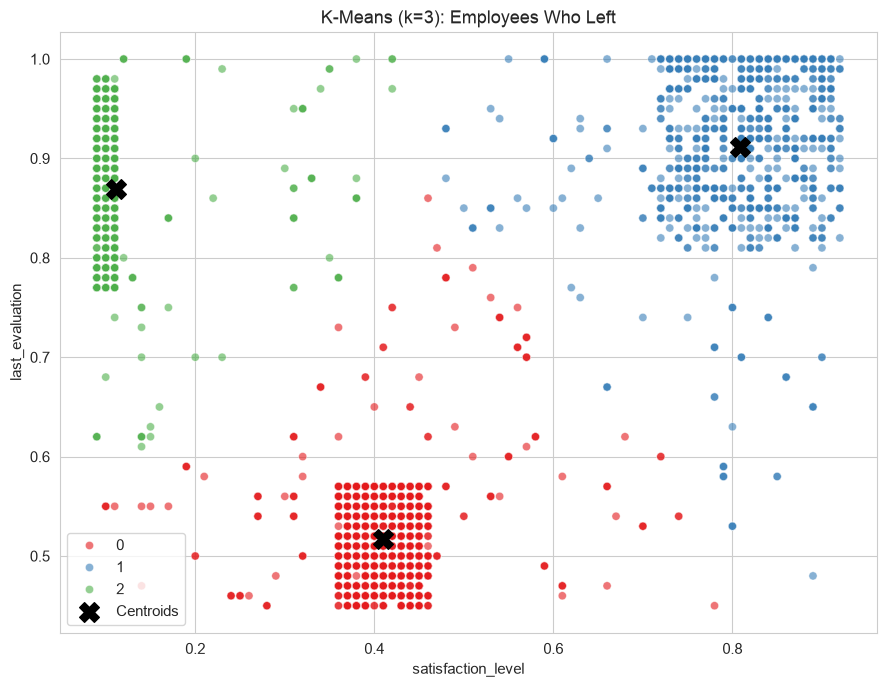

satisfaction_level       last_evaluation      
                      mean count            mean count
cluster                                               
0                 0.410145  1650        0.516982  1650
1                 0.808516   977        0.911709   977
2                 0.111155   944        0.869301   944

In [10]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=left_emp, x='satisfaction_level', y='last_evaluation',
    hue='cluster', palette='Set1', alpha=0.6, s=35
)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', s=200, marker='X', label='Centroids')
plt.title('K-Means (k=3): Employees Who Left')
plt.legend()
plt.tight_layout()
plt.show()

profile = left_emp.groupby('cluster')[['satisfaction_level', 'last_evaluation']].agg(['mean', 'count'])
display(profile)

**Thoughts on leaver clusters (typical pattern in this dataset):**
1. **Low satisfaction / lower–mid evaluation** — disengaged employees; fix culture, role fit, manager support.
2. **High evaluation / low satisfaction** — high performers who are unhappy (flight risk stars); prioritize recognition, pay, growth.
3. **High evaluation / high satisfaction** — often overworked hard-chargers still leaving; check hours, projects, burnout.

Exact labels follow the cluster centers printed above.

## 5. Handle Class Imbalance with SMOTE

### 5.1 Pre-process — Categorical to Numerical

In [11]:
# Separate categorical and numeric variables
categorical_cols = ['Department', 'salary']
numeric_cols = [c for c in df.columns if c not in categorical_cols + ['left']]

cat_df = pd.get_dummies(df[categorical_cols], drop_first=False)
num_df = df[numeric_cols].copy()

X = pd.concat([num_df, cat_df], axis=1)
y = df['left'].copy()

print('Feature matrix shape:', X.shape)
print('Features:', X.columns.tolist())
print('Class balance before split:')
print(y.value_counts())

Feature matrix shape: (14999, 20)
Features: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'Department_IT', 'Department_RandD', 'Department_accounting', 'Department_hr', 'Department_management', 'Department_marketing', 'Department_product_mng', 'Department_sales', 'Department_support', 'Department_technical', 'salary_high', 'salary_low', 'salary_medium']
Class balance before split:
left
0    11428
1     3571
Name: count, dtype: int64


### 5.2 Stratified Train/Test Split (80:20, random_state=123) + SMOTE

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)

print('Before SMOTE — train left counts:')
print(y_train.value_counts())

smote = SMOTE(random_state=123)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE — train left counts:')
print(pd.Series(y_train_res).value_counts())
print(f'\nTrain (resampled): {X_train_res.shape}, Test: {X_test.shape}')

Before SMOTE — train left counts:
left
0    9142
1    2857
Name: count, dtype: int64

After SMOTE — train left counts:
left
0    9142
1    9142
Name: count, dtype: int64

Train (resampled): (18284, 20), Test: (3000, 20)


## 6. 5-Fold Cross-Validation Model Training

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=123),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=123, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=123)
}

cv_reports = {}
cv_preds = {}

for name, model in models.items():
    print('=' * 60)
    print(name)
    print('=' * 60)
    # Cross-validated predictions on resampled training data
    y_pred_cv = cross_val_predict(model, X_train_res, y_train_res, cv=cv, n_jobs=-1)
    cv_preds[name] = y_pred_cv
    report = classification_report(y_train_res, y_pred_cv, digits=3)
    cv_reports[name] = report
    print(report)

    # Fit on full resampled train for later test evaluation
    model.fit(X_train_res, y_train_res)
    models[name] = model

Logistic Regression


              precision    recall  f1-score   support

           0      0.816     0.796     0.806      9142
           1      0.801     0.821     0.811      9142

    accuracy                          0.809     18284
   macro avg      0.809     0.809     0.809     18284
weighted avg      0.809     0.809     0.809     18284



Random Forest


              precision    recall  f1-score   support

           0      0.976     0.995     0.985      9142
           1      0.995     0.975     0.985      9142

    accuracy                          0.985     18284
   macro avg      0.985     0.985     0.985     18284
weighted avg      0.985     0.985     0.985     18284



Gradient Boosting


              precision    recall  f1-score   support

           0      0.950     0.977     0.963      9142
           1      0.976     0.948     0.962      9142

    accuracy                          0.962     18284
   macro avg      0.963     0.962     0.962     18284
weighted avg      0.963     0.962     0.962     18284



## 7. Best Model, ROC/AUC, Confusion Matrix & Metric Choice

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.783,0.533,0.720,0.612,0.821
Random Forest,0.989,0.978,0.978,0.978,0.995
Gradient Boosting,0.964,0.920,0.930,0.925,0.986


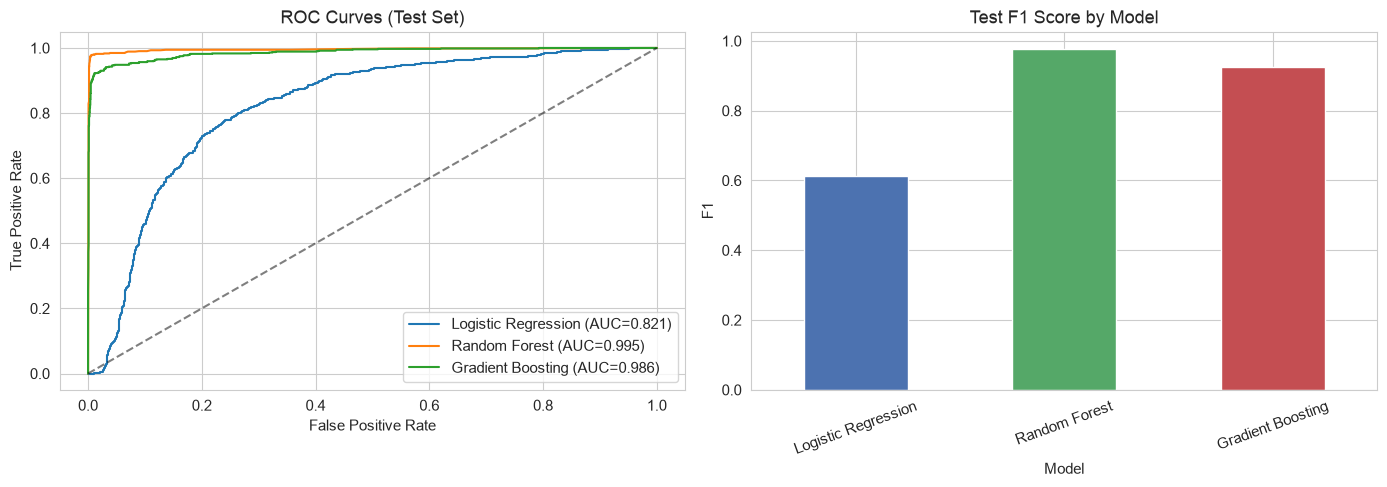


Best model by F1 on test set: Random Forest


In [14]:
results = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves on test set
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    y_pred = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': auc
    })

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (Test Set)')
axes[0].legend()

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(3))
results_df['F1'].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_title('Test F1 Score by Model')
axes[1].set_ylabel('F1')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

best_model_name = results_df['F1'].idxmax()
best_model = models[best_model_name]
print(f'\nBest model by F1 on test set: {best_model_name}')

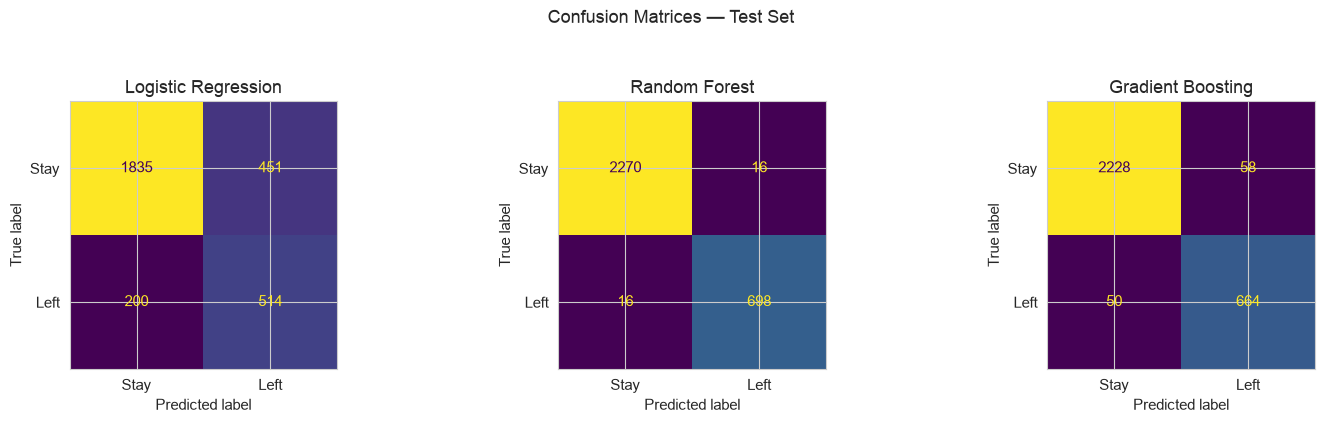

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Left']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion Matrices — Test Set', y=1.05)
plt.tight_layout()
plt.show()

### Recall vs Precision — Which Metric Matters?

For **employee turnover**, **Recall** is generally more important than Precision for the positive class (`left=1`):

- **False Negative** (predict stay, but they leave) means we miss a flight risk and lose talent/cost of replacement.
- **False Positive** (predict leave, but they stay) mainly costs extra retention outreach — usually cheaper than a surprise resignation.

We still monitor Precision and F1 so we do not overwhelm HR with false alarms. **ROC-AUC** summarizes ranking quality across thresholds.

**Best model justification:** Choose the model with strongest F1 / Recall / AUC balance on the held-out test set (see table above) — typically Random Forest or Gradient Boosting on this dataset after SMOTE.

## 8. Retention Strategies by Risk Zone

Employees in each risk zone (test set):
Safe Zone (Green)            2184
Low-Risk Zone (Yellow)        110
Medium-Risk Zone (Orange)      60
High-Risk Zone (Red)          646
Name: count, dtype: int64

Percent:
Safe Zone (Green)            72.8
Low-Risk Zone (Yellow)        3.7
Medium-Risk Zone (Orange)     2.0
High-Risk Zone (Red)         21.5
Name: count, dtype: float64


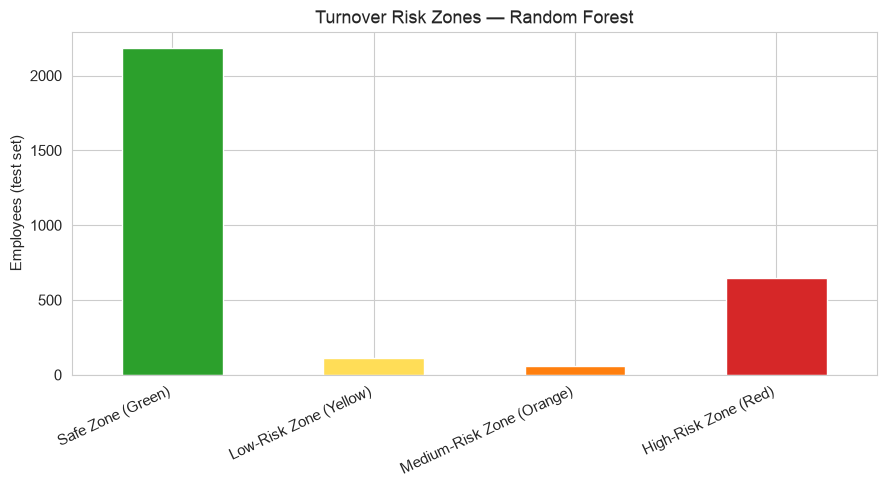

,turnover_proba,satisfaction_level,average_montly_hours,time_spend_company
risk_zone,,,,
Safe Zone (Green),0.028,0.677,198.433,3.340
Low-Risk Zone (Yellow),0.316,0.454,218.409,4.082
Medium-Risk Zone (Orange),0.771,0.560,221.050,4.183
High-Risk Zone (Red),0.993,0.429,208.825,3.884


In [16]:
# Probability of turnover on test set using best model
y_prob_best = best_model.predict_proba(X_test)[:, 1]

def risk_zone(score):
    if score < 0.20:
        return 'Safe Zone (Green)'
    elif score < 0.60:
        return 'Low-Risk Zone (Yellow)'
    elif score < 0.90:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

zones = pd.Series(y_prob_best).apply(risk_zone)
zone_order = [
    'Safe Zone (Green)',
    'Low-Risk Zone (Yellow)',
    'Medium-Risk Zone (Orange)',
    'High-Risk Zone (Red)'
]

zone_counts = zones.value_counts().reindex(zone_order)
print('Employees in each risk zone (test set):')
print(zone_counts)
print('\nPercent:')
print((zone_counts / zone_counts.sum() * 100).round(1))

plt.figure(figsize=(9, 5))
colors = ['#2ca02c', '#ffdd57', '#ff7f0e', '#d62728']
zone_counts.plot(kind='bar', color=colors)
plt.title(f'Turnover Risk Zones — {best_model_name}')
plt.ylabel('Employees (test set)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# Attach zones to test features for inspection
test_view = X_test.copy()
test_view['turnover_proba'] = y_prob_best
test_view['risk_zone'] = zones.values
test_view['actual_left'] = y_test.values
display(test_view.groupby('risk_zone')[['turnover_proba', 'satisfaction_level', 'average_montly_hours', 'time_spend_company']].mean().reindex(zone_order).round(3))

### Suggested Retention Strategies by Zone

| Zone | Score | Strategy |
|------|-------|----------|
| **Safe (Green)** | < 20% | Maintain engagement: recognition, career pathing, healthy workload. Light-touch check-ins. |
| **Low-Risk (Yellow)** | 20–60% | Monitor satisfaction & hours; offer stretch projects carefully; pulse surveys; manager 1:1s. |
| **Medium-Risk (Orange)** | 60–90% | Targeted interventions: compensation review, role clarity, reduce overload, mentorship, internal mobility. |
| **High-Risk (Red)** | > 90% | Urgent retention plan: stay interviews, counter-offers where justified, workload reset, executive sponsor for high performers. |

**Priority:** Act first on **High-Risk + high last_evaluation** employees (valuable flight risks identified in clustering).

## 9. Summary

1. **Data quality:** No missing values; class imbalance addressed with SMOTE on the training set only.
2. **EDA drivers:** Low satisfaction, extreme project loads, long hours, low salary, and mid tenure (~3–5 years) correlate with leaving.
3. **Leaver clusters:** Three groups by satisfaction × evaluation — disengaged, unhappy high performers, and saturated high performers.
4. **Models:** Logistic Regression, Random Forest, and Gradient Boosting trained with 5-fold CV; best model selected via test F1/AUC.
5. **Metric:** Prefer **Recall** (catch leavers) while tracking Precision/F1 for HR capacity.
6. **Action:** Map predicted probabilities into Green/Yellow/Orange/Red zones and apply the retention playbook above.

**Deliverable:** This notebook (`.ipynb`) meeting all course-end project steps.